# Section 1: Notebook Setup & Imports

This section initializes the environment, sets up path resolution, imports libraries for modeling and evaluation, and configures the random seed for reproducibility. We also verify CUDA availability for XGBoost.

In [1]:
import os
import sys
import random
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Define out_dir globally for 1.0 hyperparameter sweep
out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-hyperparameters-1.0"
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {out_dir}")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Output directory: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.0
Random seed set to 42
XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the Washington-only `derived_8.2` dataset. We concatenate the train and validation sets to form the `trainval` split for model training, parse dates, and extract month and year features.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)


# Section 3: Feature & Hyperparameters Configuration

In this section, we import Feature Set V3 from `dataset_metadata.py` and configure the 17 distinct XGBoost regressors. These configurations span capacity variations (tree depth, min child weight), regularization (L1/L2 penalties), random sampling ratios, and different objective loss functions (MAE, MSE, and Pseudo-Huber).

In [3]:
# Import Feature Sets from dataset_metadata for derived_8.2
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V3 = dataset_metadata.OVERALL_SELECTED_FEATURES_V3
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V3 count: {len(FEATURE_SET_V3)}")

# Define the 17 models for the hyperparameter sweep
MODELS_CONFIG = [
    # 0. Baseline MAE
    {"id": 0, "name": "Baseline (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 1. High Capacity MAE Depth 10
    {"id": 1, "name": "High Capacity Depth 10 (MAE)", "objective": "reg:absoluteerror", "max_depth": 10, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 2. High Capacity MAE Depth 12
    {"id": 2, "name": "High Capacity Depth 12 (MAE)", "objective": "reg:absoluteerror", "max_depth": 12, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 3. High Capacity MAE Child Weight 1
    {"id": 3, "name": "High Capacity Min Child Weight 1 (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 1, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 4. High Capacity MAE Low Regularization
    {"id": 4, "name": "High Capacity Low Reg (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 0.1, "reg_alpha": 0.00, "subsample": 0.9, "colsample_bytree": 0.8},
    # 5. Low Capacity MAE Depth 6
    {"id": 5, "name": "Low Capacity Depth 6 (MAE)", "objective": "reg:absoluteerror", "max_depth": 6, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 6. Low Capacity MAE Depth 4
    {"id": 6, "name": "Low Capacity Depth 4 (MAE)", "objective": "reg:absoluteerror", "max_depth": 4, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 7. Low Capacity MAE High Regularization
    {"id": 7, "name": "Low Capacity High Reg (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 10.0, "reg_alpha": 1.00, "subsample": 0.9, "colsample_bytree": 0.8},
    # 8. Low Capacity MAE Conservative Sampling
    {"id": 8, "name": "Low Capacity Sampling (MAE)", "objective": "reg:absoluteerror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.7, "colsample_bytree": 0.6},
    # 9. MSE Baseline
    {"id": 9, "name": "Baseline (MSE)", "objective": "reg:squarederror", "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 10. Huber Slope 1.0
    {"id": 10, "name": "Huber Slope 1.0", "objective": "reg:pseudohubererror", "huber_slope": 1.0, "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 11. Huber Slope 0.1
    {"id": 11, "name": "Huber Slope 0.1", "objective": "reg:pseudohubererror", "huber_slope": 0.1, "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 12. Huber Slope 5.0
    {"id": 12, "name": "Huber Slope 5.0", "objective": "reg:pseudohubererror", "huber_slope": 5.0, "max_depth": 8, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 13. MSE + Depth 10
    {"id": 13, "name": "High Capacity Depth 10 (MSE)", "objective": "reg:squarederror", "max_depth": 10, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 14. MSE + Depth 12
    {"id": 14, "name": "High Capacity Depth 12 (MSE)", "objective": "reg:squarederror", "max_depth": 12, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 15. MSE + Depth 6
    {"id": 15, "name": "Low Capacity Depth 6 (MSE)", "objective": "reg:squarederror", "max_depth": 6, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
    # 16. MSE + Depth 4
    {"id": 16, "name": "Low Capacity Depth 4 (MSE)", "objective": "reg:squarederror", "max_depth": 4, "min_child_weight": 2, "reg_lambda": 1.5, "reg_alpha": 0.03, "subsample": 0.9, "colsample_bytree": 0.8},
]

Feature Set V3 count: 47


# Section 4: Training & Timing Loop

In this section, we define the training routine for all 17 model configurations. For each model:
1. We check if the saved model weights (`xgb_model_{id}.json`) and metadata (`xgb_model_{id}_meta.json`) already exist on disk.
2. If they do, we load the model and retrieve the cached training and inference time performance from the metadata.
3. If they do not, we train the model using GPU acceleration (`device="cuda"`), measure the training and inference time performance using `time.perf_counter()`, and save both the model weights and timing metadata back to disk.
4. We generate and cache test set predictions for each configuration to use in final evaluations and plotting.

In [4]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()
X_trainval = trainval_df[FEATURE_SET_V3]
X_test = test_df[FEATURE_SET_V3]

models_dir = out_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Prepare DataFrame to hold predictions
test_predictions_df = test_df[["date", "year", "month", TARGET_COL]].copy()

# Store execution metrics dynamically
trained_models = {}

print("Starting training loop for 17 configurations...\n")
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    
    model_path = models_dir / f"xgb_model_{model_id}.json"
    meta_path = models_dir / f"xgb_model_{model_id}_meta.json"
    
    # Configure parameters
    params = {
        "objective": config["objective"],
        "random_state": SEED,
        "n_jobs": -1,
        "subsample": config["subsample"],
        "colsample_bytree": config["colsample_bytree"],
        "max_depth": config["max_depth"],
        "min_child_weight": config["min_child_weight"],
        "n_estimators": 5500,
        "learning_rate": 0.04,
        "reg_lambda": config["reg_lambda"],
        "reg_alpha": config["reg_alpha"],
        "device": XGB_DEVICE,
    }
    if "huber_slope" in config:
        params["huber_slope"] = config["huber_slope"]
        
    model = XGBRegressor()
    
    if model_path.exists() and meta_path.exists():
        print(f"[{model_id}] Loading {model_name} from disk...")
        model.load_model(str(model_path))
        with open(meta_path, "r") as f:
            meta = json.load(f)
        train_time = meta["train_time_s"]
        inference_time = meta["inference_time_s"]
        
        # Still predict to populate predictions dataframe
        preds = np.asarray(model.predict(X_test)).ravel()
    else:
        print(f"[{model_id}] Training {model_name} from scratch...")
        model = XGBRegressor(**params)
        
        # Measure training time
        t0 = time.perf_counter()
        model.fit(X_trainval, y_trainval, verbose=0)
        t1 = time.perf_counter()
        train_time = t1 - t0
        
        # Measure inference time
        t2 = time.perf_counter()
        preds = np.asarray(model.predict(X_test)).ravel()
        t3 = time.perf_counter()
        inference_time = t3 - t2
        
        # Save model and meta to disk
        model.save_model(str(model_path))
        meta = {
            "train_time_s": train_time,
            "inference_time_s": inference_time,
            "params": {k: v for k, v in params.items() if k != "device"}
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)
            
        print(f"  Training time:  {train_time:.2f}s")
        print(f"  Inference time: {inference_time:.4f}s")
        
    test_predictions_df[f"pred_{model_id}"] = preds
    config["train_time_s"] = train_time
    config["inference_time_s"] = inference_time
    trained_models[model_id] = model

print("\nAll 17 models processed.")
# Save predictions DataFrame
test_predictions_df.to_csv(out_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions to: {out_dir / 'test_predictions.csv'}")

Starting training loop for 17 configurations...

[0] Loading Baseline (MAE) from disk...


[1] Loading High Capacity Depth 10 (MAE) from disk...


[2] Loading High Capacity Depth 12 (MAE) from disk...


[3] Loading High Capacity Min Child Weight 1 (MAE) from disk...


[4] Loading High Capacity Low Reg (MAE) from disk...


...

[13] Loading High Capacity Depth 10 (MSE) from disk...


[14] Loading High Capacity Depth 12 (MSE) from disk...


[15] Loading Low Capacity Depth 6 (MSE) from disk...


[16] Loading Low Capacity Depth 4 (MSE) from disk...



All 17 models processed.
Saved test predictions to: C:\Users\pan\Documents\GitHub\MDR-Project\notebooks\experiment\derived_8.2-hyperparameters-1.0\test_predictions.csv


# Section 5: Metric Evaluation & Timing Summary

In this section, we evaluate the overall performance of all 17 model configurations on the held-out test split. We compute key statistical metrics ($R^2$, RMSE, ubRMSE, Bias, MAE, Median Absolute Error, and Pearson correlation) along with the recorded training and inference times. The results are compiled into a unified comparison table and saved to `metrics_summary.csv`.

In [5]:
# Define compute_metrics utility
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

# Compile summary metrics
summary_records = []
for config in MODELS_CONFIG:
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    
    metrics = compute_metrics(y_test, preds)
    metrics["Configuration"] = model_name
    metrics["Train Time (s)"] = config["train_time_s"]
    metrics["Inference Time (s)"] = config["inference_time_s"]
    summary_records.append(metrics)

summary_df = pd.DataFrame(summary_records)
# Reorder columns
cols_order = ["Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson", "Train Time (s)", "Inference Time (s)"]
summary_df = summary_df[cols_order]

summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)
print("===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format,
    'Train Time (s)': '{:,.2f}'.format,
    'Inference Time (s)': '{:,.4f}'.format
}))

===== COMPARATIVE PERFORMANCE & TIMING SUMMARY =====


                         Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson Train Time (s) Inference Time (s)
                        Baseline (MAE) 0.6474 0.0625 0.0589 -0.0211 0.0475   0.0364  0.8322          34.58             0.3310
          High Capacity Depth 10 (MAE) 0.6443 0.0628 0.0585 -0.0230 0.0472   0.0352  0.8339          58.77             0.3418
          High Capacity Depth 12 (MAE) 0.6350 0.0636 0.0595 -0.0225 0.0481   0.0362  0.8267         109.99             0.3511
High Capacity Min Child Weight 1 (MAE) 0.6335 0.0638 0.0602 -0.0210 0.0483   0.0369  0.8240          41.08             0.3367
           High Capacity Low Reg (MAE) 0.6443 0.0628 0.0592 -0.0211 0.0473   0.0355  0.8307          31.85             0.3297
            Low Capacity Depth 6 (MAE) 0.6199 0.0649 0.0613 -0.0214 0.0491   0.0370  0.8180          21.49             0.3129
            Low Capacity Depth 4 (MAE) 0.6046 0.0662 0.0628 -0.0211 0.0503   0.0390  0.8087          14.86           

# Section 6: Overall Residual Plots

This section generates a comprehensive grid comparison of residuals across all 17 configurations. Residuals are plotted as a function of the true soil moisture value (True vs. Residual) to diagnose structural underfitting (mean regression) and error distributions. The resulting figure is saved as `residuals_comparison.png`.

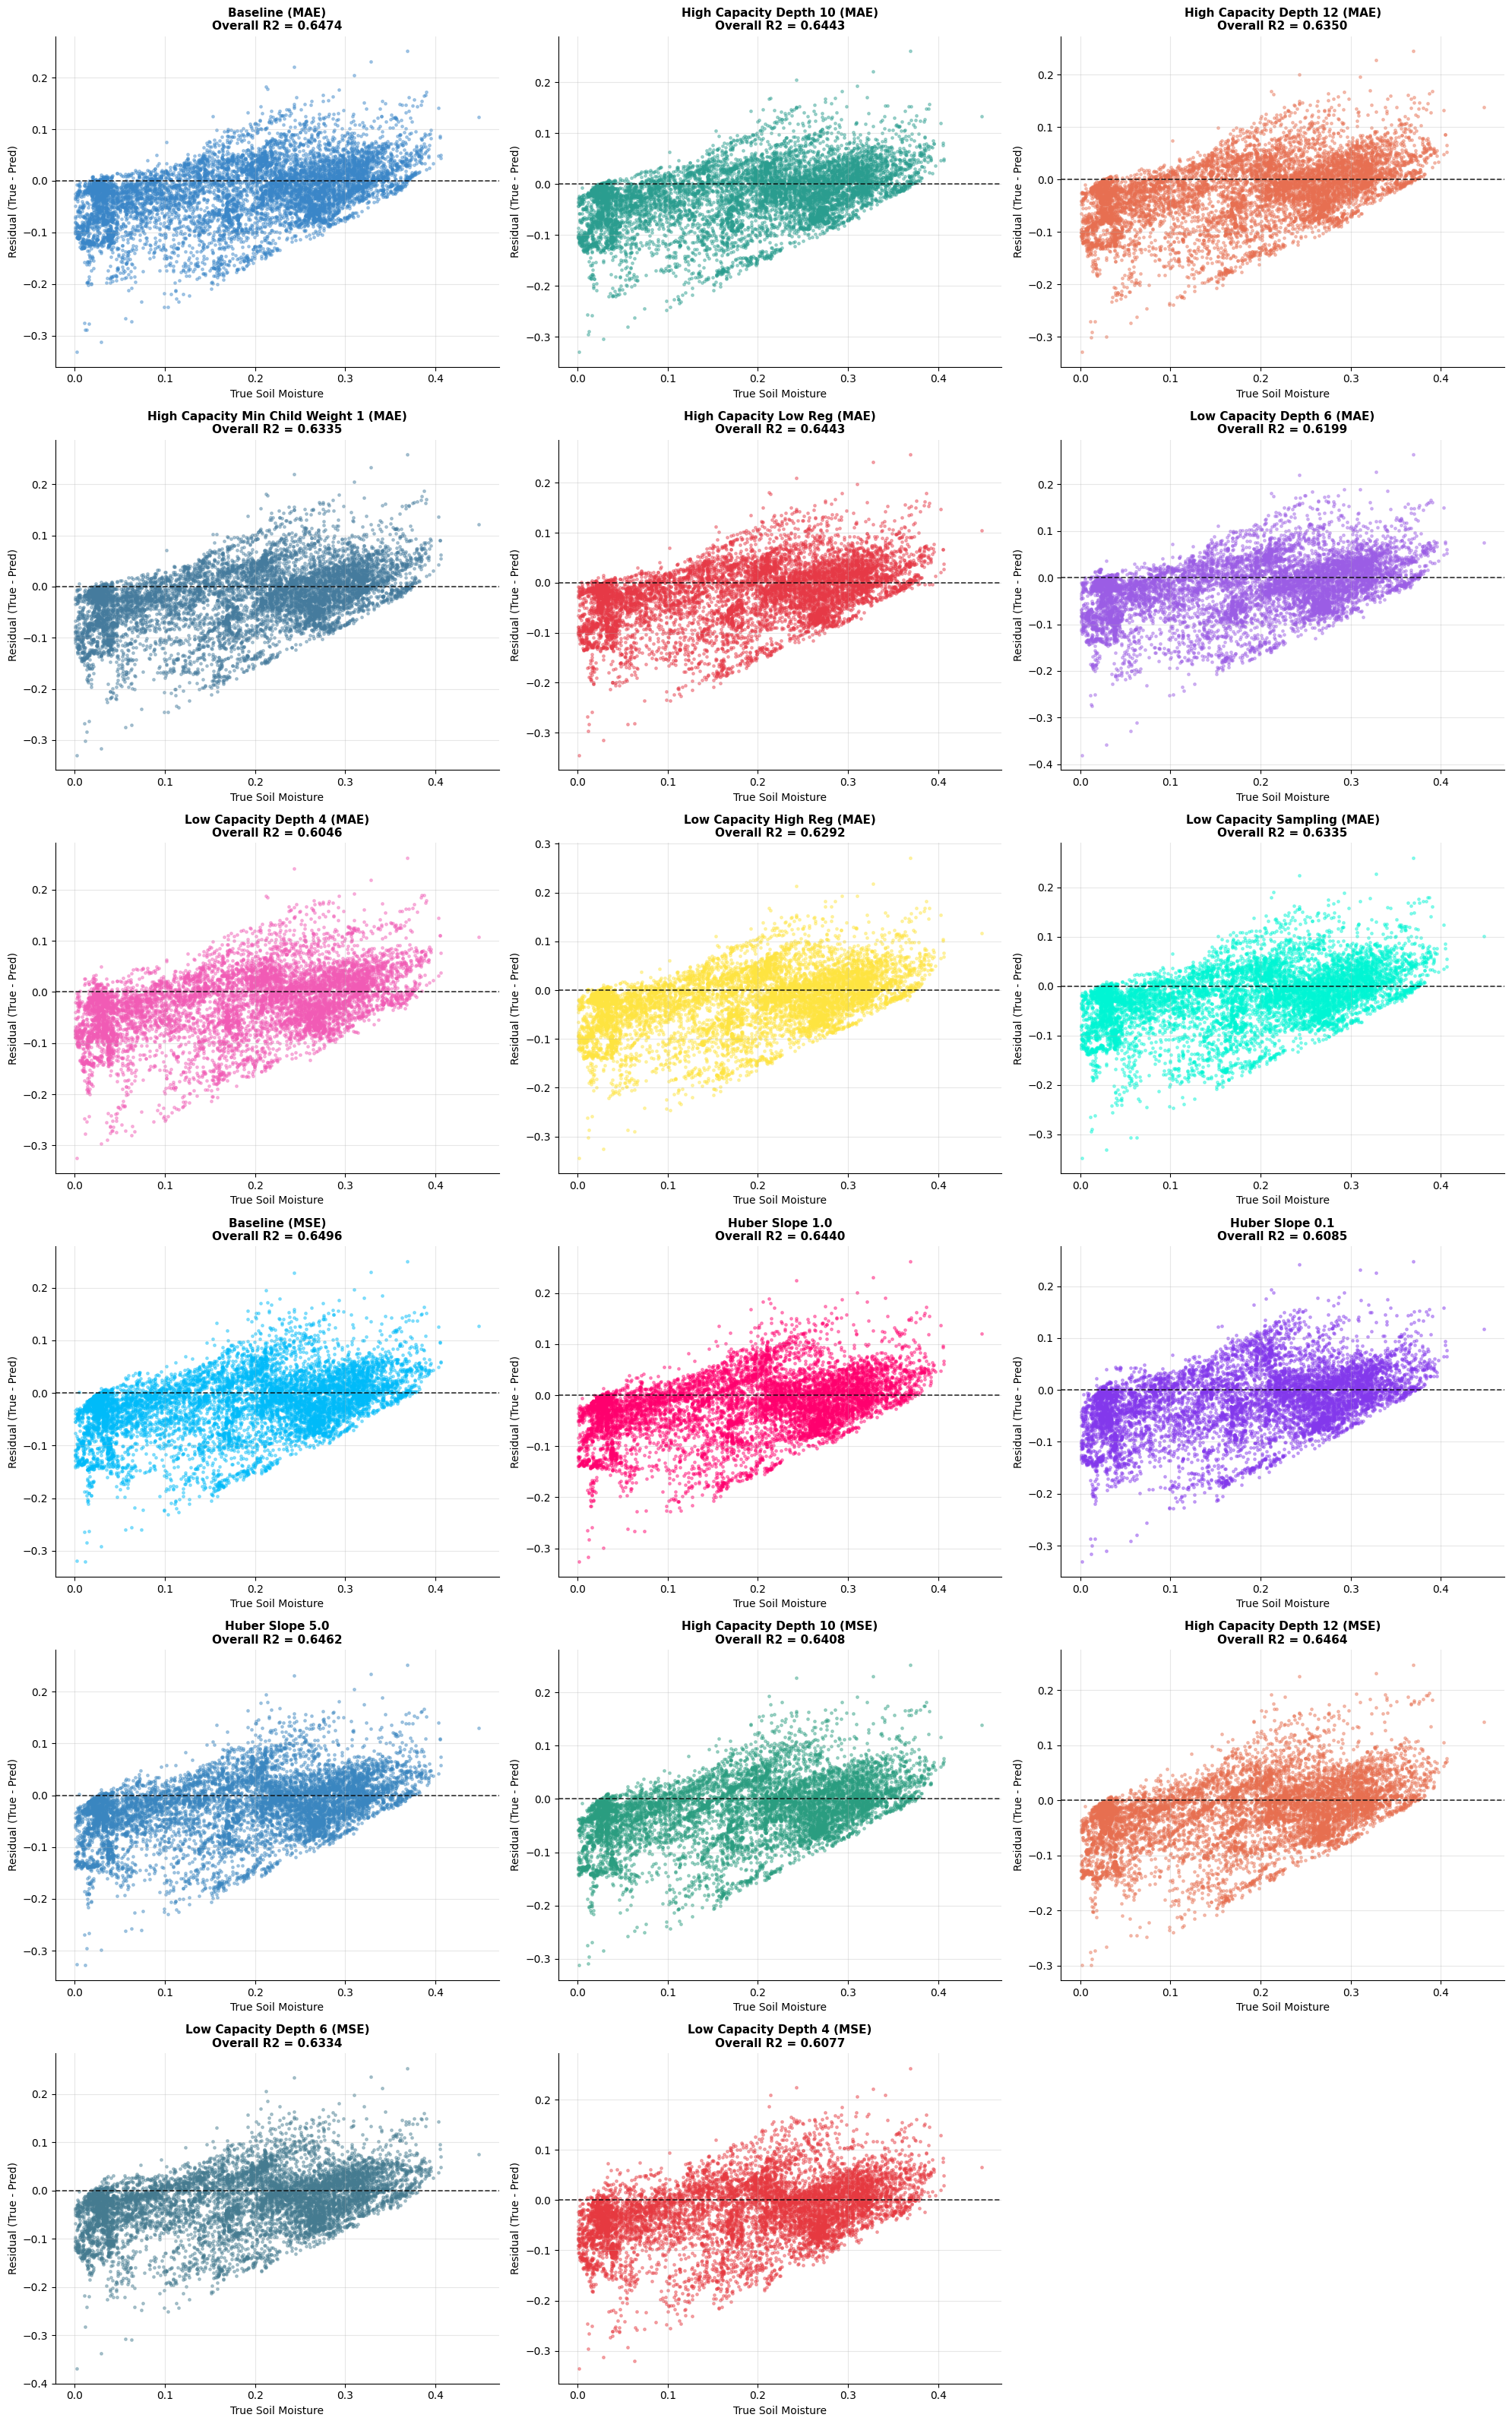

In [6]:
# Plot residuals comparison (6 rows, 3 columns = 18 axes)
fig, axes = plt.subplots(6, 3, figsize=(20, 32))
axes = axes.flatten()

# Curate some distinct colors for the plots
colors_palette = [
    '#3a86c8', '#2a9d8f', '#e76f51', '#457b9d', '#e63946', '#9b5de5', '#f15bb5', '#fee440', '#00f5d4',
    '#00bbf9', '#ff006e', '#8338ec', '#3a86c0', '#2a9d80', '#e76f50', '#457b90', '#e63940'
]

for i, config in enumerate(MODELS_CONFIG):
    model_id = config["id"]
    model_name = config["name"]
    preds = test_predictions_df[f"pred_{model_id}"]
    res = y_test - preds
    r2_val = r2_score(y_test, preds)
    
    ax = axes[i]
    ax.scatter(y_test, res, s=6, alpha=0.4, color=colors_palette[i % len(colors_palette)])
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_xlabel("True Soil Moisture", fontsize=10)
    ax.set_ylabel("Residual (True - Pred)", fontsize=10)
    ax.set_title(f"{model_name}\nOverall R2 = {r2_val:.4f}", fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide any remaining unused subplots (the 18th cell)
for j in range(len(MODELS_CONFIG), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png", dpi=200)
plt.show()

# Section 7: Year-by-Year Performance Evaluation & Residuals

In this section, we evaluate each of the 17 configurations separately on each test year (2023, 2024, and 2025) to understand their temporal generalization consistency. We calculate yearly performance metrics, compile them into `metrics_by_year.csv`, and visualize the error distributions by year in a comprehensive 17x3 residuals grid saved to `residuals_by_year.png`.

Test years identified: [np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]

===== YEAR 2023 PERFORMANCE SUMMARY =====
 Year                          Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
 2023                         Baseline (MAE) 0.6292 0.0655 0.0569 -0.0325 0.0509   0.0406  0.8503
 2023           High Capacity Depth 10 (MAE) 0.6213 0.0662 0.0571 -0.0335 0.0511   0.0403  0.8487
 2023           High Capacity Depth 12 (MAE) 0.6011 0.0680 0.0592 -0.0334 0.0526   0.0412  0.8362
 2023 High Capacity Min Child Weight 1 (MAE) 0.6130 0.0669 0.0583 -0.0328 0.0516   0.0414  0.8427
 2023            High Capacity Low Reg (MAE) 0.6328 0.0652 0.0568 -0.0319 0.0503   0.0394  0.8510
 2023             Low Capacity Depth 6 (MAE) 0.5850 0.0693 0.0608 -0.0333 0.0532   0.0402  0.8297
 2023             Low Capacity Depth 4 (MAE) 0.5522 0.0720 0.0625 -0.0358 0.0554   0.0450  0.8215
 2023            Low Capacity High Reg (MAE) 0.5998 0.0681 0.0592 -0.0335 0.0525   0.0399

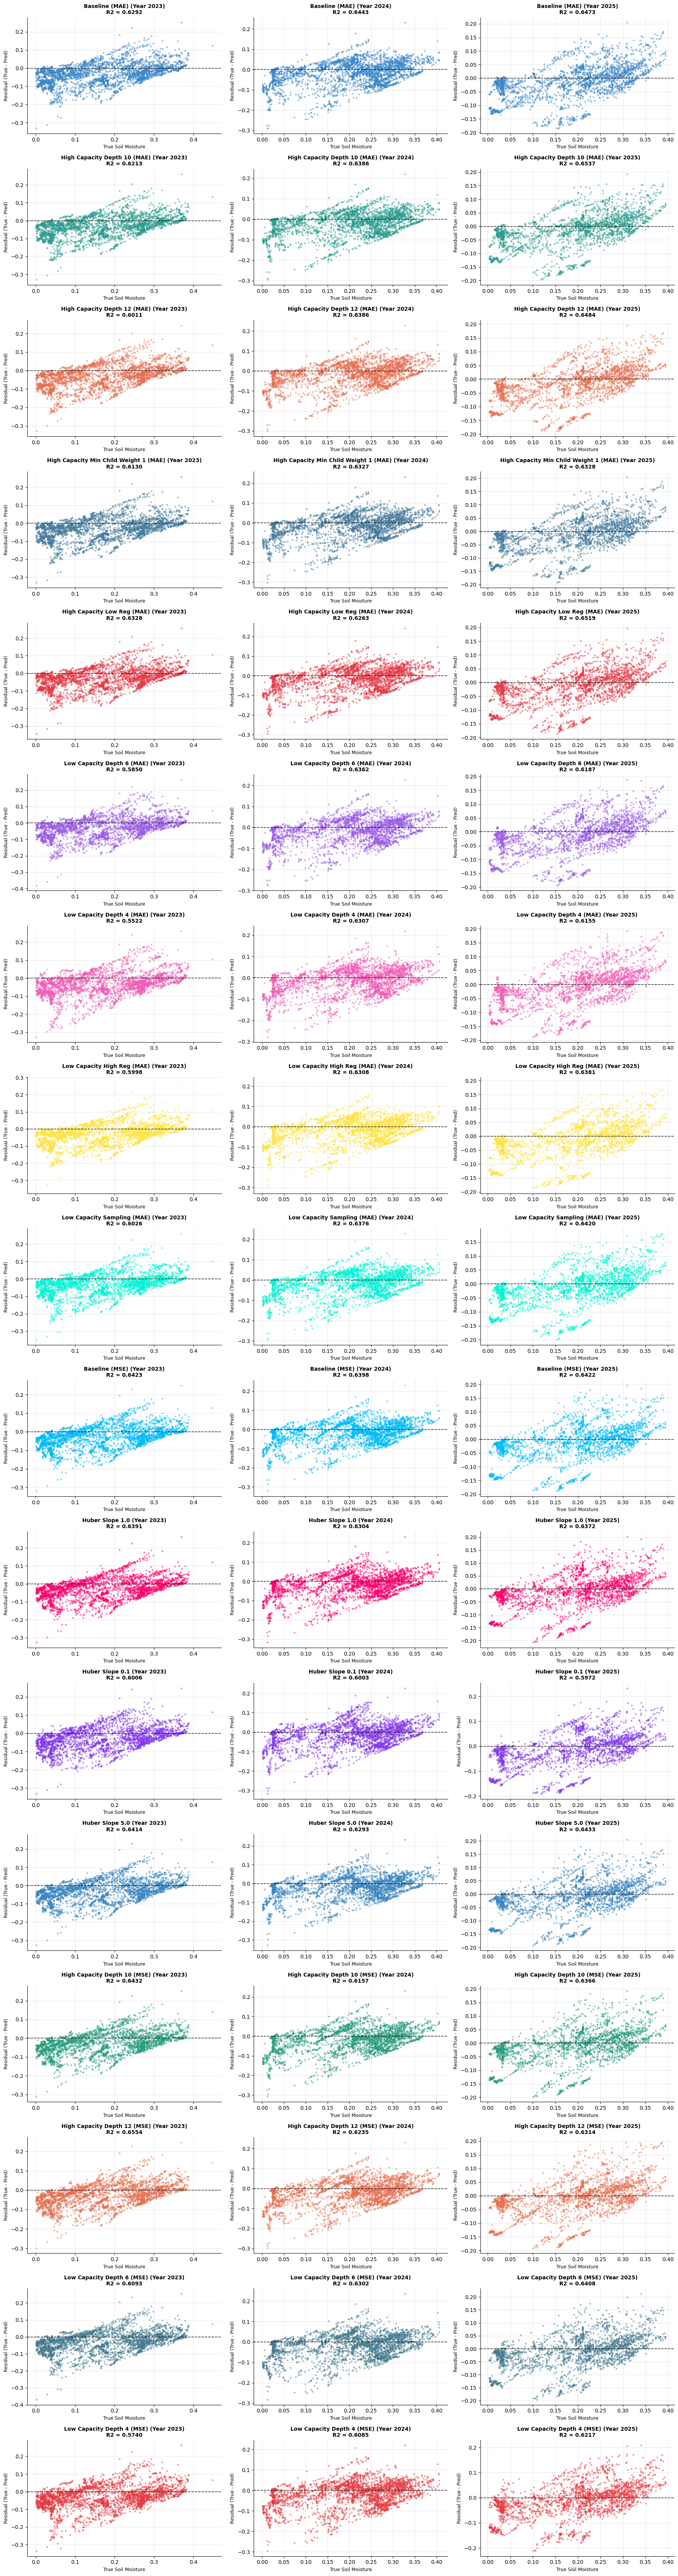

In [7]:
# Identify unique test years
test_years = sorted(test_predictions_df["year"].unique())
print(f"Test years identified: {test_years}")

yearly_records = []

for yr in test_years:
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    for config in MODELS_CONFIG:
        model_id = config["id"]
        model_name = config["name"]
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        
        metrics_yr = compute_metrics(y_test_yr, preds_yr)
        metrics_yr["Year"] = int(yr)
        metrics_yr["Configuration"] = model_name
        yearly_records.append(metrics_yr)

yearly_summary_df = pd.DataFrame(yearly_records)
# Reorder columns
cols_order_yr = ["Year", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[cols_order_yr]

# Print yearly metrics breakdown
for yr in test_years:
    print(f"\n===== YEAR {int(yr)} PERFORMANCE SUMMARY =====")
    df_yr_m = yearly_summary_df[yearly_summary_df["Year"] == int(yr)]
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot residuals by year (17 rows, 3 columns = 51 axes)
fig, axes = plt.subplots(17, 3, figsize=(18, 68))

for i, config in enumerate(MODELS_CONFIG):
    model_id = config["id"]
    model_name = config["name"]
    
    for col, yr in enumerate(test_years):
        df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
        y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
        preds_yr = test_predictions_df[test_predictions_df["year"] == yr][f"pred_{model_id}"].values
        res_yr = y_test_yr - preds_yr
        r2_yr = r2_score(y_test_yr, preds_yr)
        
        ax = axes[i, col]
        ax.scatter(y_test_yr, res_yr, s=6, alpha=0.4, color=colors_palette[i % len(colors_palette)])
        ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.set_xlabel("True Soil Moisture", fontsize=9)
        ax.set_ylabel("Residual (True - Pred)", fontsize=9)
        ax.set_title(f"{model_name} (Year {int(yr)})\nR2 = {r2_yr:.4f}", fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png", dpi=150)
plt.show()

# Section 8: Year-by-Year R2 Trend Visualization

To avoid cluttering a single line chart with 17 curves, we group the configurations into three logical families:
1. **MAE Model Family**: Investigating capacity variations (tree depth, min child weight, sampling) and regularization under the MAE objective.
2. **MSE Model Family**: Evaluating capacity (tree depth) variations under the MSE objective.
3. **Huber Model Family**: Comparing standard MAE, MSE, and Pseudo-Huber loss with different Huber slopes.

We plot the yearly R2 trend for each family side-by-side and save the visualization as `r2_by_year.png`.

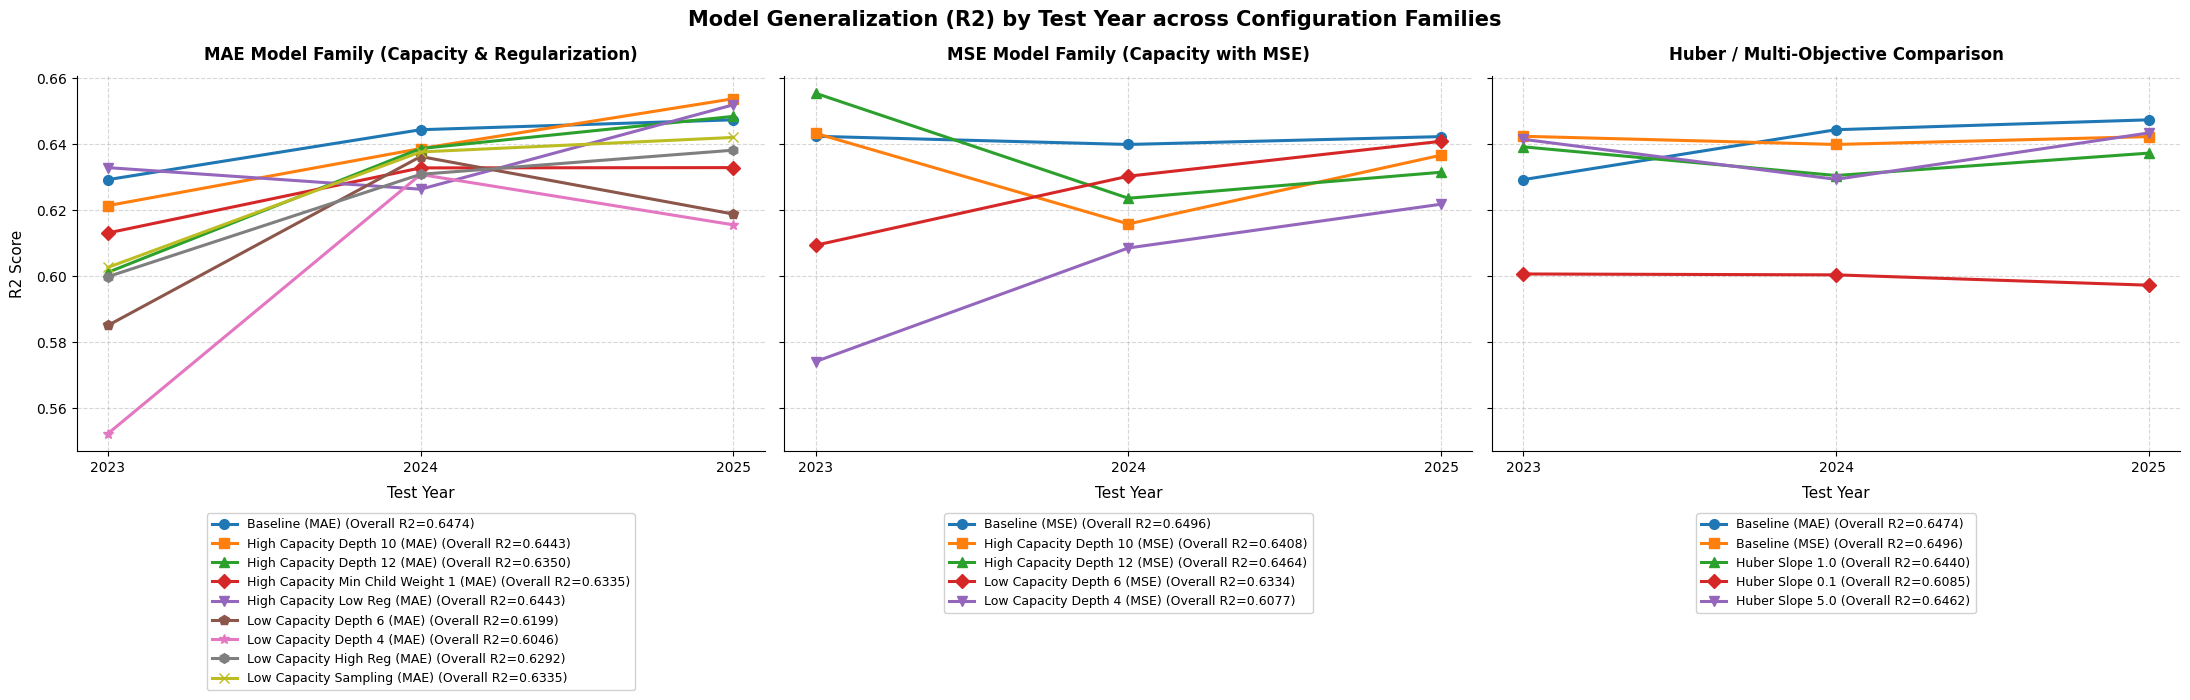

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

# Define groupings
mae_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8]
mse_ids = [9, 13, 14, 15, 16]
huber_ids = [0, 9, 10, 11, 12] # Compare baseline MAE, MSE, and Hubers

groupings = [
    ("MAE Model Family (Capacity & Regularization)", mae_ids, axes[0]),
    ("MSE Model Family (Capacity with MSE)", mse_ids, axes[1]),
    ("Huber / Multi-Objective Comparison", huber_ids, axes[2])
]

# Set up unique markers for readability
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'x', '<', '>', '8', 'd']

for title, ids, ax in groupings:
    for idx, model_id in enumerate(ids):
        config = MODELS_CONFIG[model_id]
        model_name = config["name"]
        
        df_model = yearly_summary_df[yearly_summary_df["Configuration"] == model_name].sort_values("Year")
        years = df_model["Year"].values
        r2_vals = df_model["R2"].values
        
        # Retrieve overall R2 for the legend
        overall_r2 = summary_df[summary_df["Configuration"] == model_name]["R2"].values[0]
        
        ax.plot(years, r2_vals, marker=markers[idx % len(markers)], markersize=7, linewidth=2.2,
                label=f"{model_name} (Overall R2={overall_r2:.4f})")
        
    ax.set_xticks(test_years)
    ax.set_xticklabels([str(int(y)) for y in test_years])
    ax.set_xlabel("Test Year", fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, 
              frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("R2 Score", fontsize=11, labelpad=8)
plt.suptitle("Model Generalization (R2) by Test Year across Configuration Families", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.savefig(out_dir / "r2_by_year.png", dpi=300)
plt.show()